Datos exportados correctamente.


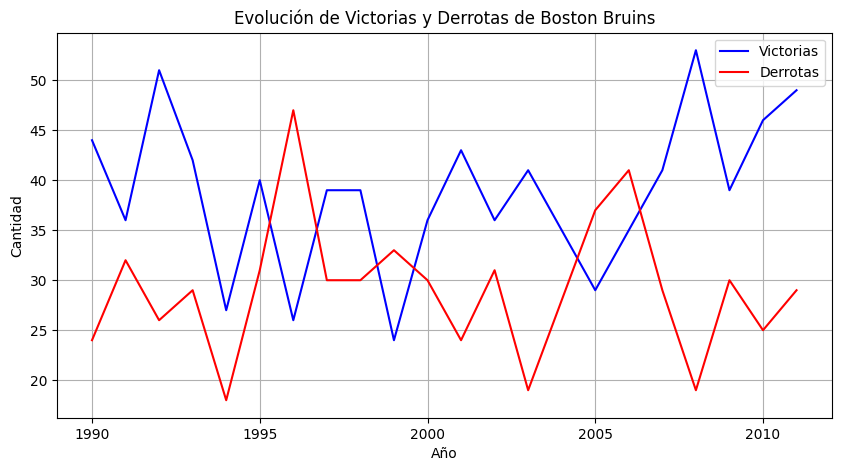

In [5]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt

base_url = "https://www.scrapethissite.com/pages/forms/"
all_rows = []

# Recorrer todas las páginas
for page in range(1, 25):
    url = f"{base_url}?page_num={page}"
    response = requests.get(url)

    if response.status_code == 200:
        soup = BeautifulSoup(response.text, 'html.parser')
        table = soup.find('table', class_='table')

        # Sacar encabezados solo una vez
        if page == 1:
            headers = [th.text.strip() for th in table.find_all('th')]

        for row in table.find_all('tr')[1:]:
            cells = [cell.text.strip() for cell in row.find_all('td')]
            if cells:
                all_rows.append(cells)

# Crear DataFrame con todos los datos
df = pd.DataFrame(all_rows, columns=headers)

# Exportar CSV sin índice
df.to_csv('equipos.csv', index=False)
print("Datos exportados correctamente.")

# Filtrar Boston Bruins
boston_bruins = df[df['Team Name'] == 'Boston Bruins'].copy()

# Convertir a numérico
boston_bruins['Year'] = boston_bruins['Year'].astype(int)
boston_bruins['Wins'] = boston_bruins['Wins'].astype(int)
boston_bruins['Losses'] = boston_bruins['Losses'].astype(int)

# Ordenar por año
boston_bruins = boston_bruins.sort_values('Year')

# Graficar evolución de los :contentReference[oaicite:0]{index=0}
plt.figure(figsize=(10, 5))
plt.plot(boston_bruins['Year'], boston_bruins['Wins'], label='Victorias', color='blue')
plt.plot(boston_bruins['Year'], boston_bruins['Losses'], label='Derrotas', color='red')

plt.title('Evolución de Victorias y Derrotas de Boston Bruins')
plt.xlabel('Año')
plt.ylabel('Cantidad')
plt.legend()
plt.grid()
plt.show()